<div style="text-align:center; background-color:#fff6e4; padding:20px; border:5px solid #f5ecda; border-radius:8px;">
    <div style="font-size:36px; font-weight:bold; color:#4A4A4A;">
        Buscando Nombre
    </div>
    <div style="font-size:24px; font-weight:bold; color:#4A4A4A;">
        Part 1: EDA &amp; Preprocessing
    </div>
    <div style="font-size:14px; font-weight:normal; color:#666; margin-top:16px;">
        Author: Jerónimo Hoyos Botero <br> 
        Created: May 2026<br>
        Last updated: May 2026
    </div>
</div>

<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Setup</h1>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Notebook Settings</strong>
</div>

In [329]:
# Automatically reload local modules before each cell run
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Imports</strong>
</div>

In [330]:
# Data manipulation
import pandas as pd
import numpy as np


# Data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

# Utils
import math

<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Data Loading</h1>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Load datasets from GitHub</strong>
</div>

In [331]:
paths = {
    "banco_sangre": r"..\data\raw\banco_sangre.csv",
    "defunciones": r"..\data\raw\defunciones.csv",
    "atenciones": r"..\data\raw\atenciones.csv"
}

dataframes = {}

for var_name, file in paths.items():
    print(f"Loading data from: {file}")
    try:
        dataframes[var_name] = pd.read_csv(file, low_memory=False)
        print(f"'{var_name}' loaded successfully. Shape: {dataframes[var_name].shape}")
    except FileNotFoundError:
        print(f"Error: File not found → {file}")
        dataframes[var_name] = None
    except pd.errors.EmptyDataError:
        print("Error: The file is empty.")
        dataframes[var_name] = None
    except pd.errors.ParserError:
        print("Error: The file content could not be parsed.")
        dataframes[var_name] = None
    except PermissionError:
        print("Error: Permission denied when accessing the file.")
        dataframes[var_name] = None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        dataframes[var_name] = None

# Asignar a variables individuales
df_banco_sangre = dataframes["banco_sangre"]
df_defunciones  = dataframes["defunciones"]
df_atenciones   = dataframes["atenciones"]

print("\nDimensiones de los DataFrames:")
print("Banco:      ", df_banco_sangre.shape)
print("Defunciones:", df_defunciones.shape)
print("Atenciones:", df_atenciones.shape)

# Limpiar memoria
del dataframes

Loading data from: ..\data\raw\banco_sangre.csv
'banco_sangre' loaded successfully. Shape: (35840, 11)
Loading data from: ..\data\raw\defunciones.csv
'defunciones' loaded successfully. Shape: (5094, 26)
Loading data from: ..\data\raw\atenciones.csv
'atenciones' loaded successfully. Shape: (221203, 12)

Dimensiones de los DataFrames:
Banco:       (35840, 11)
Defunciones: (5094, 26)
Atenciones: (221203, 12)


In [332]:
df_atenciones.head()

,AÑO,Periodo de reporte,Fecha atencion,servicio,Sexo,Cod. Aseguradora,Aseguradora,Poblacion,Departamento,edad,rango de edad,regimen
0,2022,1,02/01/2022,Ambulatorio,M,20002686.0,ALIANZA MEDELLIN ANTIOQUIA EPS SUBSIDIADO ISS ...,20 DE JULI O,ANTIOQUIA,2,1 A 4 AÑOS,SUBSIDIADO
1,2022,1,02/01/2022,Ambulatorio,M,20000362.0,"AXA COLPATRIA SEGUROS SA, SOAT",Barrio Cristobal LA AMERICA,ANTIOQUIA,35,15 A 44 AÑOS,OTRO
2,2022,1,02/01/2022,Ambulatorio,M,20000368.0,SEGUROS LA PREVISORA,Playon de Los Comuneros SANTA CRUZ,ANTIOQUIA,24,15 A 44 AÑOS,OTRO
3,2022,1,02/01/2022,Ambulatorio,M,20000366.0,SEGUROS DEL ESTADO,Aures No2 ROBLEDO,ANTIOQUIA,23,15 A 44 AÑOS,OTRO
4,2022,1,02/01/2022,Hospitalizado,M,20000368.0,SEGUROS LA PREVISORA,NaN,ANTIOQUIA,32,15 A 44 AÑOS,OTRO


<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Data Diagnostic</h1>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Columns & sample rows</strong>
</div>

In [333]:
def explorar_dfs(**dfs):
    for nombre, df in dfs.items():
        print(f"\n{nombre}  —  {df.shape[0]:,} filas × {df.shape[1]} columnas")

        info = pd.DataFrame({
            "dtype":   df.dtypes.astype(str),
            "nulos":   df.isna().sum(),
            "% nulos": (df.isna().mean()*100).round(1),
            **{f"ej {i+1}": df.iloc[i] for i in range(min(5, len(df)))},
        })

        display(info)

explorar_dfs(
    Banco=df_banco_sangre,
    Defunciones=df_defunciones,
    Atenciones=df_atenciones,
)


Banco  —  35,840 filas × 11 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
ANO,int64,0,0.0,2020,2020,2020,2020,2020
TRIMESTRE,int64,0,0.0,4,1,1,1,1
FECHA EXTRACCION,str,0,0.0,28/12/2020,01/02/2020,01/02/2020,01/02/2020,01/02/2020
RH,str,41,0.1,0+,0+,0+,0+,0+
BARRIO,str,7788,21.7,POPULAR 1,20 DE JULIO,20 DE JULIO,20 DE JULIO,20 DE JULIO
CIUDAD,str,0,0.0,MEDELLIN,MEDELLIN,MEDELLIN,MEDELLIN,MEDELLIN
EDAD,float64,2,0.0,41.0,43.0,43.0,44.0,44.0
ESTATURA,float64,79,0.2,NaN,1.74,1.74,1.6,1.6
FECHA NACIMIENTO,str,2,0.0,1982 Jan 01 12:00:00 AM,1979 Mar 12 12:00:00 AM,1979 Mar 12 12:00:00 AM,1979 Apr 21 12:00:00 AM,1979 Apr 21 12:00:00 AM
PESO,float64,41,0.1,NaN,80.0,80.0,86.0,86.0



Defunciones  —  5,094 filas × 26 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
AÑO,int64,0,0.0,2022,2022,2022,2022,2022
Trimestre,int64,0,0.0,1,1,1,1,1
SITIO DEFUNCION,str,3,0.1,HOSPITAL/CLINICA,HOSPITAL/CLINICA,HOSPITAL/CLINICA,HOSPITAL/CLINICA,HOSPITAL/CLINICA
TIPO DEFUNCION,str,0,0.0,FETAL,NO FETAL,NO FETAL,NO FETAL,NO FETAL
FECHA DEFUNCION,str,0,0.0,01/01/2022,02/01/2022,02/01/2022,02/01/2022,02/01/2022
SEXO FALLECIDO,str,1,0.0,MASCULINO,FEMENINO,FEMENINO,MASCULINO,FEMENINO
ESTADO CONYUGAL FALLECIDO,str,1307,25.7,NaN,ESTABA VIUDO(A),NaN,ESTABA VIUDO(A),NaN
EDAD FALLECIDO,float64,412,8.1,80.0,87.0,88.0,88.0,96.0
NIVEL EDUCATIVO FALLECIDO,str,1731,34.0,NaN,NaN,BASICA PRIMARIA,NaN,BASICA PRIMARIA
ULTIMO ANO APROBADO FALLECIDO,float64,2679,52.6,NaN,NaN,2.0,NaN,5.0



Atenciones  —  221,203 filas × 12 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
AÑO,int64,0,0.0,2022,2022,2022,2022,2022
Periodo de reporte,int64,0,0.0,1,1,1,1,1
Fecha atencion,str,0,0.0,02/01/2022,02/01/2022,02/01/2022,02/01/2022,02/01/2022
servicio,str,0,0.0,Ambulatorio,Ambulatorio,Ambulatorio,Ambulatorio,Hospitalizado
Sexo,str,5,0.0,M,M,M,M,M
Cod. Aseguradora,float64,4972,2.2,20002686.0,20000362.0,20000368.0,20000366.0,20000368.0
Aseguradora,str,4972,2.2,ALIANZA MEDELLIN ANTIOQUIA EPS SUBSIDIADO ISS ...,"AXA COLPATRIA SEGUROS SA, SOAT",SEGUROS LA PREVISORA,SEGUROS DEL ESTADO,SEGUROS LA PREVISORA
Poblacion,str,57998,26.2,20 DE JULI O,Barrio Cristobal LA AMERICA,Playon de Los Comuneros SANTA CRUZ,Aures No2 ROBLEDO,NaN
Departamento,str,436,0.2,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA
edad,int64,0,0.0,2,35,24,23,32


<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Preprocessing</h1>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Limpieza y estandarización</strong>
</div>

In [334]:
def unicos_df(df, columnas):
    pd.set_option("display.max_colwidth", None)
    info = pd.DataFrame({
        "dtype":    df[columnas].dtypes.astype(str),
        "n_unicos": df[columnas].nunique(),
        "unicos":   [df[col].unique().tolist() for col in columnas],
    })
    display(info)
    pd.reset_option("display.max_colwidth")


In [335]:
def estandarizar_columnas(df):
    import re
    def limpiar(col):
        col = col.strip().lower()
        col = col.replace("ñ", "n")
        col = re.sub(r"[áàäâ]", "a", col)
        col = re.sub(r"[éèëê]", "e", col)
        col = re.sub(r"[íìïî]", "i", col)
        col = re.sub(r"[óòöô]", "o", col)
        col = re.sub(r"[úùüû]", "u", col)
        col = re.sub(r"[()\/\\]", " ", col)
        col = re.sub(r"[^a-z0-9\s]", "", col)
        col = re.sub(r"\s+", "_", col)
        col = col.strip("_")
        return col

    nuevos = {col: limpiar(col) for col in df.columns}
    print("Renombrando columnas:")
    for viejo, nuevo in nuevos.items():
        if viejo != nuevo:
            print(f"  {viejo!r:35} → {nuevo!r}")
    return df.rename(columns=nuevos)

In [336]:
def estandarizar_valores(df, columnas):
    import re
    def limpiar(val):
        if not isinstance(val, str):
            return val
        val = val.strip().lower()
        val = re.sub(r"[()\/\\]", " ", val)
        val = re.sub(r"[^a-z0-9\s]", "", val)
        val = re.sub(r"\s+", "_", val)
        val = val.strip("_")
        return val

    df = df.copy()
    for col in columnas:
        df[col] = df[col].map(limpiar)
    return df

In [337]:
def boxplots_numericas(df):
    import matplotlib.pyplot as plt

    numericas = df.select_dtypes(include="number").columns
    n = len(numericas)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 4))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, numericas):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor="#d0e7fa"),
                   medianprops=dict(color="#185FA5", linewidth=2))
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_xticks([]) 
    plt.tight_layout()
    plt.show()


<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Limpieza de df_banco_sangre</strong>
</div>

In [338]:
df_banco_sangre.columns

Index(['ANO', 'TRIMESTRE', 'FECHA EXTRACCION', 'RH', 'BARRIO', 'CIUDAD',
       'EDAD', 'ESTATURA', 'FECHA NACIMIENTO', 'PESO', 'SEXO'],
      dtype='str')

In [339]:
df_banco_sangre = estandarizar_columnas(df_banco_sangre)

Renombrando columnas:
  'ANO'                               → 'ano'
  'TRIMESTRE'                         → 'trimestre'
  'FECHA EXTRACCION'                  → 'fecha_extraccion'
  'RH'                                → 'rh'
  'BARRIO'                            → 'barrio'
  'CIUDAD'                            → 'ciudad'
  'EDAD'                              → 'edad'
  'ESTATURA'                          → 'estatura'
  'FECHA NACIMIENTO'                  → 'fecha_nacimiento'
  'PESO'                              → 'peso'
  'SEXO'                              → 'sexo'


In [340]:
unicos_df(df_banco_sangre, ['ano', 'trimestre', 'rh', 'barrio', 'ciudad', 'sexo'])

,dtype,n_unicos,unicos
ano,int64,6,"[2020, 2024, 2022, 2021, 2025, 2023]"
trimestre,int64,4,"[4, 1, 2, 3]"
rh,str,8,"[0+, 0-, AB+, B+, A+, A-, AB-, B-, nan]"
barrio,str,1274,"[POPULAR 1, 20 DE JULIO, CATALUNA, VILLATINA, LAURELES, SANTA CATALINA, SAN CRISTOBAL, LAS VEGAS, SANTA MONICA, 12 DE OCTUBRE, LA MILAGROSA, SABANETA, JARDINES, ANCON 1, LA FINCA, SAN JAVIER, LLANO SANTAFE DE ANTIOQUIA, nan, SALVADOR, GUASIMALITO, ALFONSO LOPEZ, PUEBLO VIEJO, EL VERGEL, EL REMANSO, BELEN SAN BERNARDO, CALATRAVA, CABANAS, FLORESTA ALCAZARES, BELEN, SAN PIO, BELEN LAS MERCEDES, CENTRO, CALAZANS, MANRIQUE, POPULAR # 2, BOSTON, LA AMERICA, CALASANZ, MANRIQUE ORIENTAL, PORVENIR, SANTA CRUZ, SAN JOAQUIN, PEREZ, MILAGROSA, PONTEVEDRA, BELEN ALTAVISTA, ABREITO, CENTRO., LIMONAR 2, CONQUISTADORES, SUCRE, CAICEDO, CAICEDO VILLA LILIAM, SAN RAFAEL, ROBLEDO, LOS BERNAL, COLINAS DE ENCISO, SAN DIEGO, SUCRE BOSTON, LAS ANTILLAS, BOYACA LAS BRISAS, LA FLORESTA, GUAYABAL, TRAVESIAS, ENVIGADO PARQUE, BUENOS AIRES, MADERA, DUCADO, LA CASTELLANA, LA MAGNOLIA, LA MINA, PLAYITA, BELEN FATIMA, PLAYON, FLORIDA NUEVA, GRATAMIRA, LA FRONTERA, LA SEBASTIANA, LAS BRUJAS, PRADO CENTRO, CAMPO VALDES, SAN ANTONIO DE PEREIRA, POBLADO, CASTILLA, MANZANARES, VILLA DEL SOL, BELEN MIRAVALLE, ZUNIGA, ANCON 2, TRICENTENARIO, YARUMITO, LA RAYA, BETANIA, NIQUIA, SIMON BOLIVAR, FLORESTA., ANDALUCIA LA FRANCIA, PARIS, MEDELLIN, ARANJUEZ, ...]"
ciudad,str,28,"[MEDELLIN, BELLO, SABANETA, ENVIGADO, ITAGUI, DON MATIAS, COPACABANA, SAN CRISTOBAL, SAN ANTONIO DE PRADO, SAN ANTONIO DE PEREIRA, LA ESTRELLA, ESTRELLA, MARSELLA, POBLADO, RIONEGRO, FREDONIA, CALDAS, CISNEROS, SANTA BARBARA, YARUMAL, SAN VICENTE DE FERRER, AMAGA, GIRARDOTA, MARINILLA, ANDES, ARMENIA, SAN PEDRO, SONSON]"
sexo,str,2,"[M, F, nan]"


In [341]:
df_banco_sangre = estandarizar_valores(df_banco_sangre, ["barrio", "ciudad"])

In [342]:
df_banco_sangre.info()

<class 'pandas.DataFrame'>
RangeIndex: 35840 entries, 0 to 35839
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ano               35840 non-null  int64  
 1   trimestre         35840 non-null  int64  
 2   fecha_extraccion  35840 non-null  str    
 3   rh                35799 non-null  str    
 4   barrio            28052 non-null  str    
 5   ciudad            35840 non-null  str    
 6   edad              35838 non-null  float64
 7   estatura          35761 non-null  float64
 8   fecha_nacimiento  35838 non-null  str    
 9   peso              35799 non-null  float64
 10  sexo              35839 non-null  str    
dtypes: float64(3), int64(2), str(6)
memory usage: 3.0 MB


In [343]:
# Generando variable de IMC
df_banco_sangre["imc"] = df_banco_sangre["peso"] / ((df_banco_sangre["estatura"]) ** 2)
# Eliminando columnas que no aportan información relevante
df_banco_sangre = df_banco_sangre.drop(columns=["estatura", "peso", "fecha_nacimiento","ano"])
# Eliminando filas con valores nulos en columnas clave
df_banco_sangre = df_banco_sangre.dropna(subset=["rh", "imc","sexo"])
# Agregando formato de fecha a la columna de fecha de extracción
df_banco_sangre["fecha_extraccion"] = pd.to_datetime(df_banco_sangre["fecha_extraccion"], format="%d/%m/%Y")
# Colocando tipos de datos adecuados
df_banco_sangre["edad"] = df_banco_sangre["edad"].astype(int)
df_banco_sangre["trimestre"] = df_banco_sangre["trimestre"].astype(str)

In [344]:
df_banco_sangre.describe()

,fecha_extraccion,edad,imc
count,35715,35715.000000,35715.000000
mean,2022-04-16 07:32:05.947081,37.715274,26.456421
min,2020-01-02 00:00:00,14.000000,15.151133
25%,2021-01-21 00:00:00,27.000000,23.507805
50%,2022-01-13 00:00:00,36.000000,25.864512
75%,2023-01-31 00:00:00,47.000000,28.731747
max,2025-06-27 00:00:00,104.000000,88.000000
std,NaN,12.497913,4.178282


In [345]:
# Colocando un límite razonable para la edad.
df_banco_sangre = df_banco_sangre[df_banco_sangre["edad"] < 100]

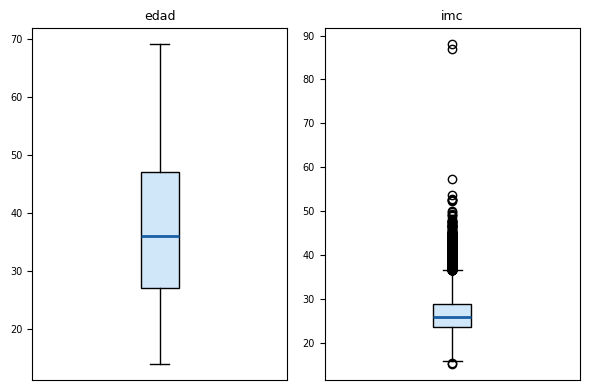

In [346]:
boxplots_numericas(df_banco_sangre)

In [347]:
df_banco_sangre.columns

Index(['trimestre', 'fecha_extraccion', 'rh', 'barrio', 'ciudad', 'edad',
       'sexo', 'imc'],
      dtype='str')

In [348]:
df_banco_sangre.duplicated().value_counts()

False    34092
True      1622
Name: count, dtype: int64

In [349]:
# Eliminando filas duplicadas porque no tiene sentido que haya donantes identicos con el mismo imc.
df_banco_sangre = df_banco_sangre.drop_duplicates()

In [350]:
df_banco_sangre["fecha_extraccion"].dt.year.value_counts(normalize=True).sort_index().mul(100).round(1)

fecha_extraccion
2020    21.8
2021    25.8
2022    25.4
2023     7.8
2024    10.1
2025     9.1
Name: proportion, dtype: float64

In [365]:
df_banco_sangre["fecha_extraccion"].dt.year.value_counts().sort_index()

fecha_extraccion
2020    7436
2021    8803
2022    8672
2023    2645
2024    3445
2025    3091
Name: count, dtype: int64

In [366]:
df_banco_sangre  = df_banco_sangre[df_banco_sangre["fecha_extraccion"].dt.year >= 2022]

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Limpieza de df_atenciones</strong>
</div>

In [351]:
df_atenciones.columns

Index(['AÑO', 'Periodo de reporte', 'Fecha atencion', 'servicio', 'Sexo',
       'Cod. Aseguradora', 'Aseguradora', 'Poblacion', 'Departamento', 'edad',
       'rango de edad', 'regimen'],
      dtype='str')

In [352]:
df_atenciones = estandarizar_columnas(df_atenciones)

Renombrando columnas:
  'AÑO'                               → 'ano'
  'Periodo de reporte'                → 'periodo_de_reporte'
  'Fecha atencion'                    → 'fecha_atencion'
  'Sexo'                              → 'sexo'
  'Cod. Aseguradora'                  → 'cod_aseguradora'
  'Aseguradora'                       → 'aseguradora'
  'Poblacion'                         → 'poblacion'
  'Departamento'                      → 'departamento'
  'rango de edad'                     → 'rango_de_edad'


In [353]:
unicos_df(df_atenciones, ['ano', 'periodo_de_reporte', 'servicio', 'sexo', 'aseguradora', 'poblacion','departamento', 'regimen'])

,dtype,n_unicos,unicos
ano,int64,5,"[2022, 2023, 2024, 2025, 2026]"
periodo_de_reporte,int64,4,"[1, 2, 3, 4]"
servicio,str,4,"[Ambulatorio, Hospitalizado, AMBULATORIO, HOSPITALIZADO]"
sexo,str,3,"[M, F, nan, I]"
aseguradora,str,285,"[ALIANZA MEDELLIN ANTIOQUIA EPS SUBSIDIADO ISS 2000, AXA COLPATRIA SEGUROS SA, SOAT, SEGUROS LA PREVISORA, SEGUROS DEL ESTADO, MALLAMAS E.P.S. INDIGENA, SUBSIDIADO, DIRECCION GENERAL DE SANIDAD MI, DEPTO ANTIOQUIA SSSA, ISS 2000, REGIONAL ASEGURAMIENTO EN SALUD (POLICIA ANTIOQUIA, ALIANZA MED - ANT EPS SAS - CON CONTRIBUTIVO ISS 2, ECOOPSOS EPS S.A.S SUBSIDIADO, ASMET SALUD EPS-S SAS, SUBSIDIADO, EPS SANITAS S.A.S, nan, DISPENSARIO MEDICO MEDELLIN, SANIDAD MILITAR, ALIANZA MEDELLIN ANTIOQUIA NO P SUBSIDIADO ISS 200, EPS Y MED PREPAP SURAMERICANA CONTRIBUTIVO SO, COOSALUD EPS-S SA, SUBSIDIADO, COMPANIA MUNDIAL DE SEGUROS, NUEVA EPS-S S.A, REGIMEN SUBSIDIADO, ESE HOSPITAL GENERAL DE MEDELLI DESCUENTOS DEL 50%, ASOCIACION INDIGENA DEL CAUCA, SUBSIDIADO, COMFACHOCO EPS-S, SUBSIDIADO, SUMIMEDICAL S.A.S., ISS 2000, DEPTO ANTIOQUIA SSSA TUTELAS, VINCULADOS PUROS ISS, EPS Y MED PREPAP SURAMERICANA PLAN COMPLEMENTARIO, LIBERTY SEGUROS SA, COMFACHOCO EPS, CONTRIBUTIVO, EPS EMPRESA MUTUAL SER, EPS-S EMPRESA MUTUAL SER, NUEVA EPS S.A, ADRES, SEGURO DE VIDA SURAMERICANA S.A ARL RIESGOS LABORA, UNION TEMPORAL RUTA AUTOINMUNES UTA, CAJA DE COMPENSACION FLIAR DE S SUBSIDIADO, EPS - S FAMISANAR, COMPANIA MUNDIAL DE SEGUROS, SOAT, EPS SALUD TOTAL, EPS-S CAJACOPI, SEGUROS GENERALES SURAMERICANA SOAT, EPS CCF COMPENSAR, AXA COLPATRIA SEGUROS DE VIDA S ARL RIESGOS LABORA, ASEGURADORA SOLIDARIA DE COLOMB SOAT, MAPFRE SEGUROS GENERALES DE COL SOAT, CAPITAL SALUD EPSS SAS, ORGANIZACION INTER PARA LAS MIG OIM, FIDEICOMISO FONDO NAL DE SALUD, COOMEVA E.P.S., EPS FAMISANAR, COOSALUD EPS SA, CONTRIBUTIVO, COOSALUD EPS-S SA NO PBS, SUBSIDIADO, EPS-S CONVIDA, REGIMEN SUBSIDIADO, ANAS WAYUU EPSI, EPS Y MED PREPAP SURAMERICANA SUBSIDIADO SO, FONDO PROT. ASEG.SOLIDARIA COL, SEGURO ESTUDIANTIL, POSITIVA CIA. DE SEGUROS S.A., ARL, EPS-S SALUD TOTAL, REGIMEN SUBSIDIADO, MUNICIPIO DE MEDELLIN, PRIMER NIVEL, ECOOPSOS EPS S.A.S CONTRIBUTIVO, D.L.S. BELLO, EPS-S EMPRESA MUTUAL SER NO PBS REGIMEN SUBSIDIADO, COMFACHOCO EPS-S NO PBS, SUBSIDIADO, EMSSANAR SAS, CONTRIBUTIVO, SEGUROS COMERCIALES BOLIVAR SA, SOAT, EPS-S SANITAS S.A.S, COMPANIA SEGUROS BOLIVAR SA ARL ARL, EPS-S COMFAMILIAR DEL HUILA, EPS-S COMFAORIENTE, EPS-S CCF COMFENALCO VALLE, EPS Y MED PREPAP SURAMERICANA S NO PBS SUBSIDIADO, EPS-S COOMEVA SA, CAPITAL SALUD EPS SAS, EPS S COMFAGUAJIRA, SUBSIDIADO, SEGUROS DE VIDA SURAMERICANA S. POLIZAS DE SEGUROS, EMSSANAR SAS, SUBSIDIADO, ASOCIACION INDIGENA DEL CAUCA, CONTRIBUTIVO, ASOCIACION INDIGENA DELCAUCA NO, MEDIMAS EPS-S S.A.S - SUBSIDIAD SUBSIDIADO MANUAL, EPS-S COOMEVA SA NO PBS, SUBSIDIADO, GOBERNACION DEL MAGDALENA, EPS-S CAJACOPI META, EPS-S PIJAOS SALUD, REGIMEN SUBSIDIADO, CCF CAJACOPI ATLANTICO, CONTRIBUTIVO, DEPTO ANTIOQUIA DSSA TUTELAS-ME TUTELAS VINCULADOS, COLMENA, RIESGO LABORALES, EPS-S SALUD TOTAL NO PBS, REGIMEN SUBSIDIADO, EPS-S CAJACOPI NO PBS, NUEVA EPS-S S.A NO PBS, REGIMEN SUBSIDIADO, DUSAKAWI EPSS, MEDIMAS EPS S.A.S CONTRIBUTIVO CONTRIBUTIVO MANUAL, TISSUE BANK, ASMET SALUD EPS-S NO PBS, SUBSIDIADO, ESE HOSPITAL GENERAL DE MEDELLI GARANTIAS Y EVENTO, UNIVERSIDAD DE ANTIOQUIA, DEPTO ANTIOQUIA SSSA - MEDICAME VINCULADO PURO - M, EPS-S CCF COMPENSAR, IKE ASISTENCIA COLOMBIA S A, POLIZA DE VIAJE, SERVICIO OCCIDENTAL DE SALUD, SERVICIO OCCIDENTAL DE SALUD, SUBSIDIADO, HMREM DIREC GRAL SAN MIL, FID PAT AUT FIDUCIARIA LA PREVI, ...]"
poblacion,str,6481,"[20 DE JULI O, Barrio Cristobal LA AMERICA, Playon de Los Comuneros SANTA CRUZ, Aures No2 ROBLEDO, nan, SUPIA SUPIA, BARRIO LA IGUANA, Buenos Aires BUENOS AIRES, EL SALVADOR, PABLO SEXTO, Campo Valdes No2 MANRIQUE, BELLO BARRIO ZAMORA, Popular POPULAR 1, El Rincon BELEN, Manrique Oriental MANRIQUE, Robledo ROBLEDO, CAICEDO, SALGAR SALGAR, Fuente Clara ROBLEDO, SAN A

In [354]:
df_atenciones = df_atenciones.rename(columns={"periodo_de_reporte": "trimestre","poblacion": "barrio"})

In [355]:
df_atenciones = estandarizar_valores(df_atenciones, ["trimestre", "aseguradora", "barrio", "departamento", "regimen"])

In [356]:
df_atenciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 221203 entries, 0 to 221202
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ano              221203 non-null  int64  
 1   trimestre        221203 non-null  int64  
 2   fecha_atencion   221203 non-null  str    
 3   servicio         221203 non-null  str    
 4   sexo             221198 non-null  str    
 5   cod_aseguradora  216231 non-null  float64
 6   aseguradora      216231 non-null  str    
 7   barrio           163205 non-null  str    
 8   departamento     220767 non-null  str    
 9   edad             221203 non-null  int64  
 10  rango_de_edad    221203 non-null  str    
 11  regimen          221203 non-null  str    
dtypes: float64(1), int64(3), str(8)
memory usage: 20.3 MB


In [357]:
df_atenciones = df_atenciones.drop(columns=["cod_aseguradora", "rango_de_edad","ano"])
df_atenciones = df_atenciones[df_atenciones["sexo"] != "I"]
df_atenciones = df_atenciones.dropna(subset=["sexo", "departamento"])

df_atenciones["fecha_atencion"] = pd.to_datetime(df_atenciones["fecha_atencion"], format="%d/%m/%Y")
df_atenciones["edad"] = df_atenciones["edad"].astype(int)
df_atenciones["trimestre"] = df_atenciones["trimestre"].astype(str)

In [358]:
df_atenciones.describe()

,fecha_atencion,edad
count,220760,220760.000000
mean,2023-11-26 19:42:49.639427,40.240795
min,2022-01-02 00:00:00,0.000000
25%,2022-08-09 00:00:00,21.000000
50%,2023-03-29 00:00:00,38.000000
75%,2025-05-10 00:00:00,62.000000
max,2026-03-31 00:00:00,132.000000
std,NaN,25.040967


In [359]:
# Colocando un límite razonable para la edad.
df_atenciones = df_atenciones[df_atenciones["edad"] < 100]

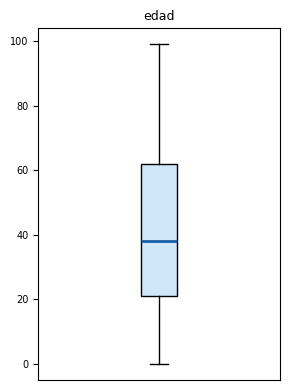

In [360]:
boxplots_numericas(df_atenciones)

In [361]:
df_atenciones.duplicated().value_counts()

False    211025
True       9686
Name: count, dtype: int64

In [362]:
df_atenciones = df_atenciones.drop_duplicates()

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Limpieza de df_defunciones</strong>
</div>

<div style="background-color:#2c699d; color:white; padding:15px; border-radius:6px;">
    <h1 style="margin:0px">Monthly Time Series</h1>
</div>

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Build monthly series</strong>
</div>

In [363]:
# Donations per month
serie_banco = (
    banco.groupby(pd.Grouper(key="fecha_extraccion", freq="ME"))
    .size()
    .reset_index(name="donaciones")
)

# Deaths per month
serie_def = (
    defunciones.groupby(pd.Grouper(key="fecha_defuncion", freq="ME"))
    .size()
    .reset_index(name="defunciones")
)

# Attended population per month
serie_pob = (
    poblacion.groupby(pd.Grouper(key="fecha_atencion", freq="ME"))
    .size()
    .reset_index(name="atenciones")
)

# Rename date columns and merge
serie_def   = serie_def.rename(columns={"fecha_defuncion": "fecha"})
serie_pob   = serie_pob.rename(columns={"fecha_atencion":  "fecha"})
serie_banco = serie_banco.rename(columns={"fecha_extraccion": "fecha"})

serie = serie_banco.merge(serie_def, on="fecha", how="left").merge(
    serie_pob, on="fecha", how="left"
)

print(serie.tail(10))

NameError: name 'banco' is not defined

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Plot monthly series</strong>
</div>

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

sns.lineplot(
    data=serie, x="fecha", y="donaciones",
    ax=axes[0], color="steelblue", linewidth=2, marker="o", markersize=4,
)
axes[0].set_title("Donaciones mensuales", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Cantidad", fontsize=11)
axes[0].grid(True, alpha=0.3)

sns.lineplot(
    data=serie, x="fecha", y="defunciones",
    ax=axes[1], color="tomato", linewidth=2, marker="o", markersize=4,
)
axes[1].set_title("Defunciones mensuales", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Cantidad", fontsize=11)
axes[1].grid(True, alpha=0.3)

sns.lineplot(
    data=serie, x="fecha", y="atenciones",
    ax=axes[2], color="seagreen", linewidth=2, marker="o", markersize=4,
)
axes[2].set_title("Atenciones mensuales", fontsize=14, fontweight="bold")
axes[2].set_ylabel("Cantidad", fontsize=11)
axes[2].set_xlabel("Fecha", fontsize=11)
axes[2].grid(True, alpha=0.3)

axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Detect incomplete months</strong>
</div>

In [ ]:
# Flag months with abnormally low donations (below p10)
umbral = serie["donaciones"].quantile(0.10)
serie["dato_incompleto"] = (serie["donaciones"] < umbral).astype(int)
print(serie[serie["dato_incompleto"] == 1][["fecha", "donaciones"]])

<div style="background-color:#e8f4fd; padding:15px; border:3px solid #d0e7fa; border-radius:6px;">
    <strong style="color:#000000;">Date ranges per dataset</strong>
</div>

In [ ]:
print("Banco:      ", banco["fecha_extraccion"].min(), "→", banco["fecha_extraccion"].max())
print("Defunciones:", defunciones["fecha_defuncion"].min(), "→", defunciones["fecha_defuncion"].max())
print("Población:  ", poblacion["fecha_atencion"].min(), "→", poblacion["fecha_atencion"].max())